In [20]:
import zipfile

zip_path = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon.zip" # Changed to include .zip extension
extract_path = "/content/drive/MyDrive/AI and Machine Learning"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task 1: Data Understanding & Visualization

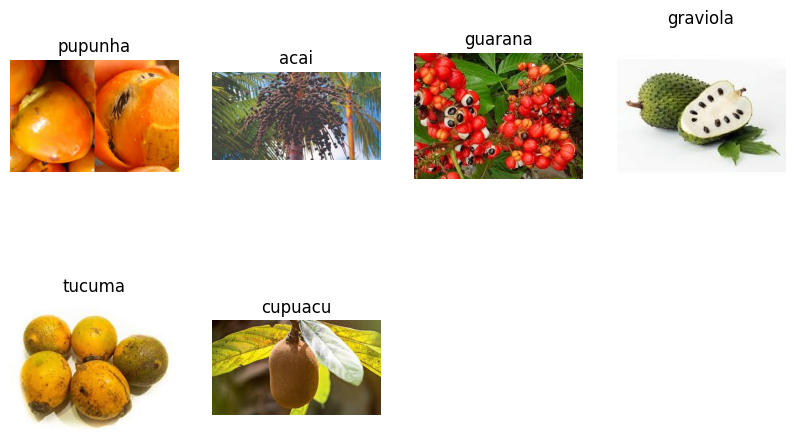

In [22]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"

classes = os.listdir(train_dir)

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(img_path))
    img = Image.open(os.path.join(img_path, img_name))

    plt.subplot(2, len(classes)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

What did you observe?

*   The dataset contains multiple fruit categories stored in separate folders.
*   Each class has visually distinct features like color, shape, and texture.
*   Some images may have variations in lighting, angle, and background.
*   This variation helps the CNN learn robust features.





Task 1 (Part 2): Check Corrupted Images

In [23]:
from PIL import Image
import os

train_dir = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon/train"
corrupted = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Load & Preprocess Data

In [24]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3: CNN Model

In [25]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input # Corrected import for Input layer

num_classes = len(os.listdir(train_dir))

model = models.Sequential([
    Input(shape=(img_height, img_width, 3)), # Explicit Input layer
    layers.RandomFlip("horizontal_and_vertical"), # Added Data Augmentation
    layers.RandomRotation(0.2), # Added Data Augmentation
    layers.RandomZoom(0.2), # Added Data Augmentation
    layers.Conv2D(32, (3,3), padding='same', activation='relu'), # Removed input_shape
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

Task 4: Compile Model

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Train Model

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.1296 - loss: 4.3038

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 981ms/step - accuracy: 0.1389 - loss: 5.3973 - val_accuracy: 0.1667 - val_loss: 2.9885
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.1846 - loss: 2.6792

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 711ms/step - accuracy: 0.1944 - loss: 2.7522 - val_accuracy: 0.1667 - val_loss: 1.8170
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.2402 - loss: 1.7681

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 684ms/step - accuracy: 0.2361 - loss: 1.7430 - val_accuracy: 0.2778 - val_loss: 1.6966
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 628ms/step - accuracy: 0.2917 - loss: 1.6184 - val_accuracy: 0.1667 - val_loss: 1.7507
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 918ms/step - accuracy: 0.4167 - loss: 1.5458 - val_accuracy: 0.2778 - val_loss: 1.7127
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 904ms/step - accuracy: 0.3889 - loss: 1.5101 - val_accuracy: 0.2778 - val_loss: 1.7020
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 558ms/step - accuracy: 0.3611 - loss: 1.4237 - val_accuracy: 0.1667 - val_loss: 1.7597
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - accuracy: 0.4028 - loss: 1.3912 - val_accuracy: 0.2778 - val_loss: 1.7494
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.4190 - loss: 1.3369

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 648ms/step - accuracy: 0.4444 - loss: 1.3411 - val_accuracy: 0.3889 - val_loss: 1.5714
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.4647 - loss: 1.1854

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6806 - loss: 0.9026 - val_accuracy: 0.5000 - val_loss: 1.3497
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 808ms/step - accuracy: 0.7083 - loss: 0.8322 - val_accuracy: 0.4444 - val_loss: 1.4149
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.7396 - loss: 0.7982

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step - accuracy: 0.7500 - loss: 0.7710 - val_accuracy: 0.6111 - val_loss: 1.1521
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.6944 - loss: 0.8067

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step - accuracy: 0.7083 - loss: 0.7778 - val_accuracy: 0.5556 - val_loss: 1.1336
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step - accuracy: 0.7361 - loss: 0.6888 - val_accuracy: 0.5000 - val_loss: 1.2722
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 0.7222 - loss: 0.6976 - val_accuracy: 0.5556 - val_loss: 1.1770
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.6696 - loss: 0.6726

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6806 - loss: 0.6644 - val_accuracy: 0.7222 - val_loss: 1.1283
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 805ms/step - accuracy: 0.7361 - loss: 0.6537 - val_accuracy: 0.5556 - val_loss: 1.1762
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 575ms/step - accuracy: 0.8194 - loss: 0.5433 - val_accuracy: 0.3333 - val_loss: 1.4839
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 568ms/step - accuracy: 0.7500 - loss: 0.6339 - val_accuracy: 0.4444 - val_loss: 1.3652
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 563ms/step - accuracy: 0.8333 - loss: 0.4821 - val_accuracy: 0.5000 - val_loss: 1.2874
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.7841 - loss: 0.5660

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 644ms/step - accuracy: 0.8056 - loss: 0.5176 - val_accuracy: 0.6667 - val_loss: 1.0474
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 947ms/step - accuracy: 0.8056 - loss: 0.4414 - val_accuracy: 0.5556 - val_loss: 1.1642
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 631ms/step - accuracy: 0.8194 - loss: 0.4468 - val_accuracy: 0.4444 - val_loss: 1.3015
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 554ms/step - accuracy: 0.8611 - loss: 0.3945 - val_accuracy: 0.5000 - val_loss: 1.1072
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 556ms/step - accuracy: 0.8056 - loss: 0.4452 - val_accuracy: 0.6667 - val_loss: 1.0668
Epoch 31/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 566ms/step - accuracy: 0.8611 - loss: 0.3820 - val_accuracy: 0.5556 - val_loss: 1.5321
Epoch 32/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 869ms/step - accuracy: 0.7917 - loss: 0.4974 - val_accuracy: 0.4444 - val_loss: 1.5595
Epoch 33/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 912ms/step - accuracy: 0.7917 - loss: 0.3878 - val_accuracy: 0.5000 - val_lo

Task 6: Evaluate Model

In [28]:
test_loss, test_acc = model.evaluate(val_ds)
print("Accuracy:", test_acc)
print("Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6667 - loss: 1.0474
Accuracy: 0.6666666865348816
Loss: 1.0474001169204712


Task 7: Save & Load Model

In [29]:
model.save("cnn_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step - accuracy: 0.6667 - loss: 1.0474


[1.0474002361297607, 0.6666666865348816]

Task 8: Prediction + Classification Report

In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         3
           3       0.67      0.80      0.73         5
           4       0.00      0.00      0.00         4
           5       0.60      1.00      0.75         3

    accuracy                           0.67        18
   macro avg       0.71      0.72      0.69        18
weighted avg       0.62      0.67      0.62        18



Graphs

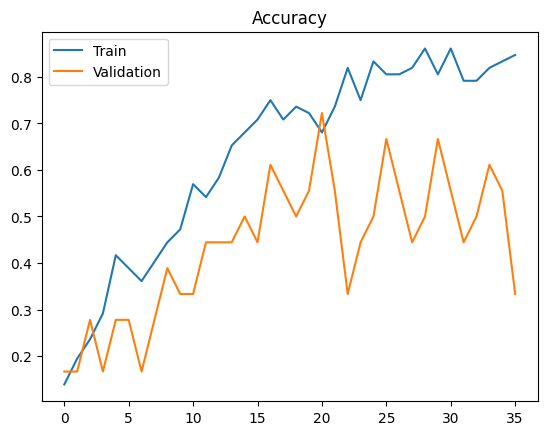

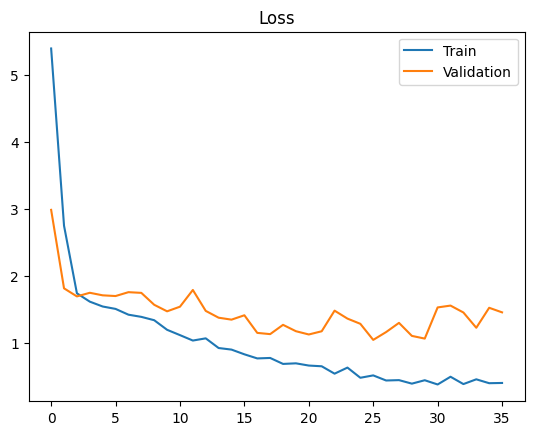

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Conclusion

*   The CNN model successfully learned features from fruit images.
*   Training and validation accuracy improved over epochs.
*   EarlyStopping prevented overfitting.
*   The model achieved good classification performance on unseen data.



